# 1: EDA

## IBM Watson Employee Attrition Dataset
This notebook inspects the raw training set prior to making any cleaning or modeling decisions.  The dataset was obtained from Kaggle.  The test set is removed since the set in Kaggle does not include the an attrition target column.  We will train, validate, and/or test using a split from the train dataset.  Also, since this is a synthetic dataset, we will use this to create a viable model where it can later be trained on real actual data at some point in the future.

## 1. Imports and Configuration

In [1]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import (
    TARGET,
    ID_COLUMN,
    TRAIN_RAW_PATH
)

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

print("Project root:", PROJECT_ROOT)
print("Training data:", TRAIN_RAW_PATH)

Project root: C:\Users\jeffh\PycharmProjects\employee-attrition
Training data: C:\Users\jeffh\PycharmProjects\employee-attrition\data\raw\train.csv


## 2. Load the Dataset

In [2]:
train = pd.read_csv(TRAIN_RAW_PATH)
print(f"Train shape: {train.shape}")

display(train.head())

Train shape: (1058, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


## 3. Column types, cardinality, and examples

In [3]:
column_audit = pd.DataFrame({
    "dtype": train.dtypes.astype(str),
    "non_null": train.notna().sum(),
    "missing": train.isna().sum(),
    "missing_pct": train.isna().mean() * 100,
    "unique_values": train.nunique(dropna=False),
})

column_audit["sample_values"] = [
    ", ".join(map(str, train[col].dropna().unique()[:5]))
    for col in train.columns
]

display(column_audit.sort_values(["unique_values", "dtype"]))

,dtype,non_null,missing,missing_pct,unique_values,sample_values
EmployeeCount,int64,1058,0,0.000,1,1
StandardHours,int64,1058,0,0.000,1,80
Over18,str,1058,0,0.000,1,Y
Attrition,int64,1058,0,0.000,2,"1, 0"
PerformanceRating,int64,1058,0,0.000,2,"3, 4"
Gender,str,1058,0,0.000,2,"Female, Male"
OverTime,str,1058,0,0.000,2,"Yes, No"
BusinessTravel,str,1058,0,0.000,3,"Travel_Rarely, Travel_Frequently, Non-Travel"
Department,str,1058,0,0.000,3,"Sales, Research & Development, Human Resources"
MaritalStatus,str,1058,0,0.000,3,"Single, Married, Divorced"


In [4]:
const_cols = [
    col for col in train.columns
    if train[col].nunique(dropna=False) <= 1
]

unique_per_row_columns = [
    col for col in train.columns
    if train[col].nunique(dropna=False) == len(train)
]

print("Constant columns:", const_cols)
print("Unique-per-row columns:", unique_per_row_columns)
print(f"{ID_COLUMN} is unique:", train[ID_COLUMN].is_unique)

Constant columns: ['EmployeeCount', 'Over18', 'StandardHours']
Unique-per-row columns: ['EmployeeNumber']
EmployeeNumber is unique: True


## 4. Missing Values

In [5]:
train_missing = train.isna().sum()

missing_report = pd.DataFrame({
    "train_missing": train_missing,
    "train_missing_pct": train_missing / len(train) * 100
})

flagged_missing = missing_report[
    (missing_report["train_missing"] > 0)
]

if flagged_missing.empty:
    print("No missing values were found in train.")
else:
    display(flagged_missing.sort_values("train_missing_pct", ascending=False))

No missing values were found in train.


## 5. Check for Duplicates (Rows and Employee IDs)

In [6]:
print("Duplicate full rows in train:", train.duplicated().sum())
print("Duplicate employee IDs in train:", train[ID_COLUMN].duplicated().sum())

Duplicate full rows in train: 0
Duplicate employee IDs in train: 0


## 6. Check for Class Imbalance
Depending on the model, we may need to adjust for the imbalance to prevent the model from returning False nearly all the time, since returning False would give an accuracy of 83%.

In [7]:
target_counts = train[TARGET].value_counts().sort_index()
target_rates = train[TARGET].value_counts(normalize=True).sort_index() * 100

target_summary = pd.DataFrame({
    "count": target_counts,
    "percent": target_rates
})

display(target_summary)

majority_accuracy = target_counts.max() / target_counts.sum()
print(f"Naive majority-class accuracy: {majority_accuracy:.3%}")

,count,percent
Attrition,,
0,879,83.081
1,179,16.919


Naive majority-class accuracy: 83.081%


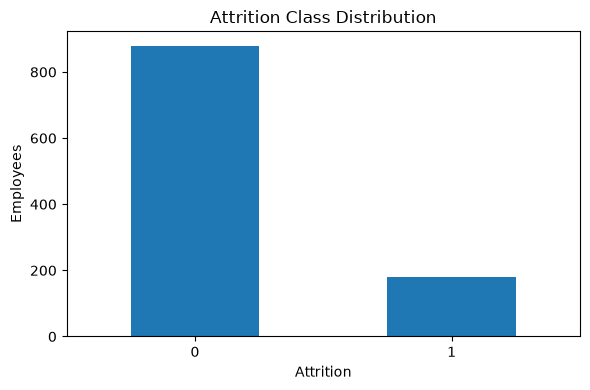

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))
target_counts.plot(kind="bar", ax=ax)
ax.set_title("Attrition Class Distribution")
ax.set_xlabel("Attrition")
ax.set_ylabel("Employees")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

## 7. Numeric Descriptive Statistics

In [9]:
num_cols = train.select_dtypes(include=np.number).columns.tolist()
num_preds = [c for c in num_cols if c != TARGET]

num_sum = train[num_preds].describe().T
num_sum["median"] = train[num_preds].median()
num_sum["skew"] = train[num_preds].skew()

num_sum = num_sum[
    ["count", "mean", "median", "std", "min", "25%", "50%", "75%", "max", "skew"]
]

display(
    num_sum.sort_values(
        "skew", key=lambda s: s.abs(), ascending=False
    )
)

,count,mean,median,std,min,25%,50%,75%,max,skew
YearsSinceLastPromotion,"1,058.000",2.203,1.000,3.267,0.000,0.000,1.000,3.000,15.000,1.981
PerformanceRating,"1,058.000",3.150,3.000,0.358,3.000,3.000,3.000,3.000,4.000,1.960
YearsAtCompany,"1,058.000",7.065,5.000,6.265,0.000,3.000,5.000,9.000,40.000,1.779
MonthlyIncome,"1,058.000","6,625.945","4,903.500","4,837.695","1,009.000","2,900.250","4,903.500","8,736.500","19,999.000",1.304
TotalWorkingYears,"1,058.000",11.436,10.000,8.016,0.000,6.000,10.000,16.000,40.000,1.083
NumCompaniesWorked,"1,058.000",2.707,2.000,2.524,0.000,1.000,2.000,4.000,9.000,1.017
DistanceFromHome,"1,058.000",8.978,7.000,8.041,1.000,2.000,7.000,13.000,29.000,1.007
StockOptionLevel,"1,058.000",0.763,1.000,0.838,0.000,0.000,1.000,1.000,3.000,1.002
JobLevel,"1,058.000",2.091,2.000,1.137,1.000,1.000,2.000,3.000,5.000,0.984
YearsInCurrentRole,"1,058.000",4.261,3.000,3.617,0.000,2.000,3.000,7.000,18.000,0.904


## 8. IQR Outliers
Outliers are worth investigating.  The do not tell us if the record is valid.

In [10]:
outliers = []

for col in num_preds:
    if train[col].nunique() <= 2:
        continue

    q1 = train[col].quantile(0.25)
    q3 = train[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    mask = (train[col] < lower) | (train[col] > upper)

    outliers.append({
        "feature": col,
        "lower_bound": lower,
        "upper_bound": upper,
        "flagged_rows": int(mask.sum()),
        "flagged_pct": mask.mean() * 100,
        "observed_min": train[col].min(),
        "observed_max": train[col].max(),
    })

outlier_report = pd.DataFrame(outliers).sort_values(
    "flagged_pct", ascending=False
)

display(outlier_report)

,feature,lower_bound,upper_bound,flagged_rows,flagged_pct,observed_min,observed_max
17,TrainingTimesLastYear,0.500,4.500,174,16.446,0,6
21,YearsSinceLastPromotion,-4.500,7.500,80,7.561,0,15
19,YearsAtCompany,-6.000,18.000,79,7.467,0,40
10,MonthlyIncome,"-5,854.125","17,490.875",64,6.049,1009,19999
15,StockOptionLevel,-1.500,2.500,55,5.198,0,3
12,NumCompaniesWorked,-3.500,8.500,43,4.064,0,9
16,TotalWorkingYears,-9.000,31.000,29,2.741,0,40
20,YearsInCurrentRole,-5.500,14.500,15,1.418,0,18
22,YearsWithCurrManager,-5.500,14.500,12,1.134,0,17
4,EmployeeNumber,-741.375,"2,207.625",0,0.000,1,1487


## 9. Test for Unrealistic Values

In [11]:
unrealistic_value_check = {
    "Age below 18": train["Age"] < 18,
    "Negative DistanceFromHome": train["DistanceFromHome"] < 0,
    "Negative MonthlyIncome": train["MonthlyIncome"] < 0,
    "Negative TotalWorkingYears": train["TotalWorkingYears"] < 0,
    "TotalWorkingYears > Age": train["TotalWorkingYears"] > train["Age"],
    "YearsAtCompany > TotalWorkingYears":
        train["YearsAtCompany"] > train["TotalWorkingYears"],
    "YearsInCurrentRole > YearsAtCompany":
        train["YearsInCurrentRole"] > train["YearsAtCompany"],
    "YearsWithCurrManager > YearsAtCompany":
        train["YearsWithCurrManager"] > train["YearsAtCompany"],
    "YearsSinceLastPromotion > YearsAtCompany":
        train["YearsSinceLastPromotion"] > train["YearsAtCompany"],
}

unrealistic_value_check_results = pd.DataFrame({
    "check": unrealistic_value_check.keys(),
    "violations": [int(mask.sum()) for mask in unrealistic_value_check.values()],
})

display(unrealistic_value_check_results)

,check,violations
0,Age below 18,0
1,Negative DistanceFromHome,0
2,Negative MonthlyIncome,0
3,Negative TotalWorkingYears,0
4,TotalWorkingYears > Age,0
5,YearsAtCompany > TotalWorkingYears,0
6,YearsInCurrentRole > YearsAtCompany,0
7,YearsWithCurrManager > YearsAtCompany,0
8,YearsSinceLastPromotion > YearsAtCompany,0


## 10. Categorical Features

In [12]:
cat_col = train.select_dtypes(include="object").columns.tolist()
cat_preds = [c for c in cat_col if c != TARGET]

cat_sum = []

for col in cat_preds:
    counts = train[col].value_counts(dropna=False)
    cat_sum.append({
        "feature": col,
        "n_categories": train[col].nunique(dropna=False),
        "most_common": counts.index[0],
        "most_common_count": counts.iloc[0],
        "least_common_count": counts.iloc[-1],
    })

display(
    pd.DataFrame(cat_sum)
    .sort_values("n_categories", ascending=False)
)

,feature,n_categories,most_common,most_common_count,least_common_count
4,JobRole,9,Sales Executive,232,30
2,EducationField,6,Life Sciences,436,15
1,Department,3,Research & Development,701,38
0,BusinessTravel,3,Travel_Rarely,746,107
5,MaritalStatus,3,Married,464,242
3,Gender,2,Male,620,438
7,OverTime,2,No,751,307
6,Over18,1,Y,1058,1058


## 11. Numeric Distributions

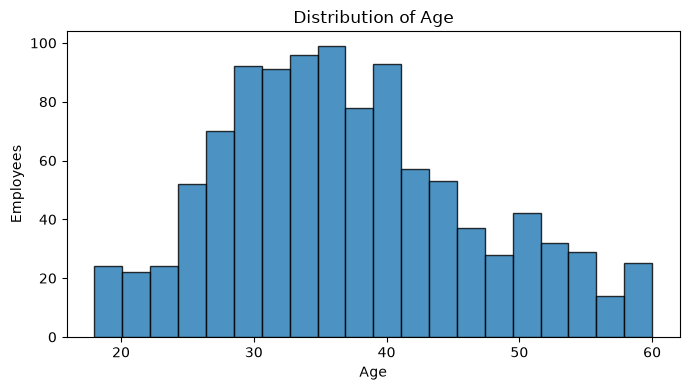

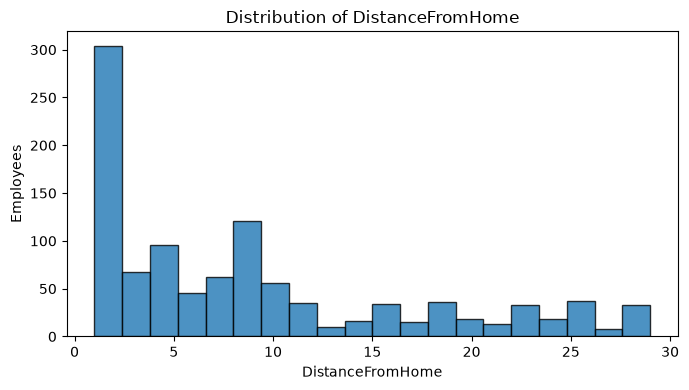

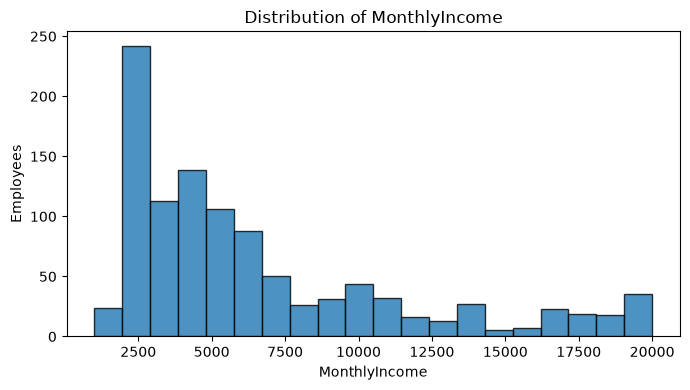

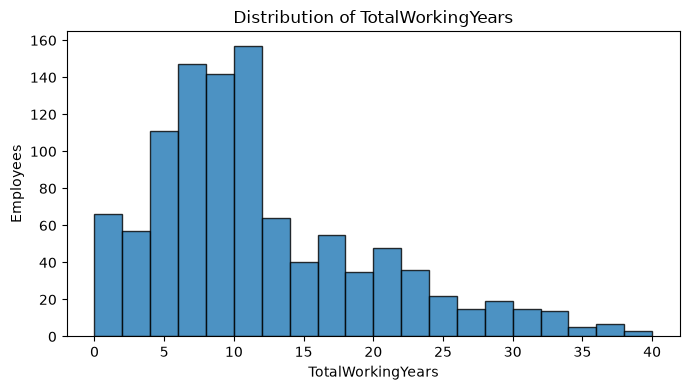

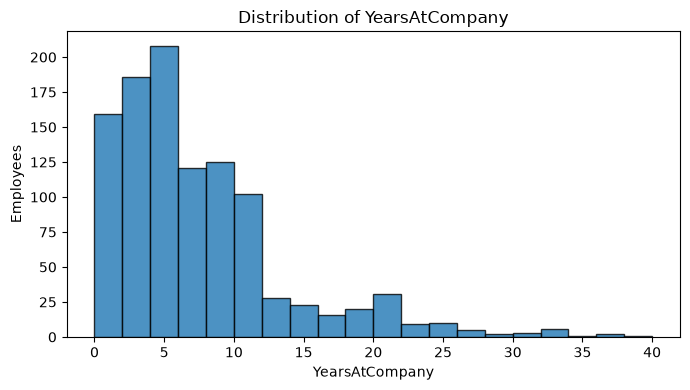

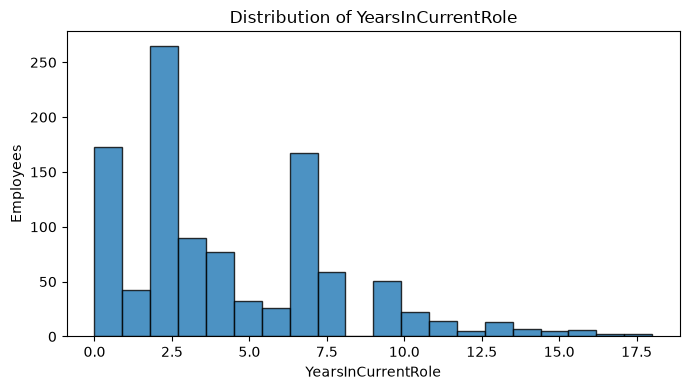

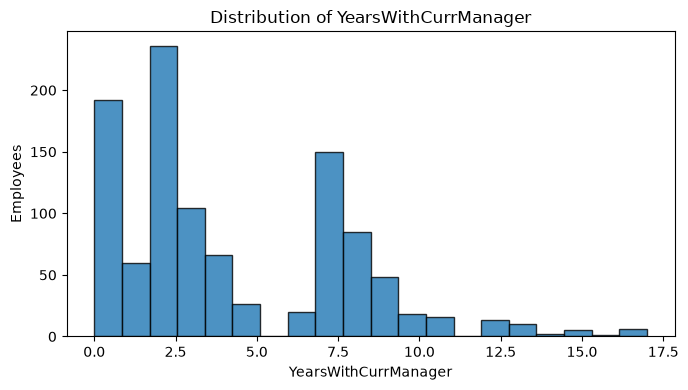

In [13]:
num_dist = [
    "Age",
    "DistanceFromHome",
    "MonthlyIncome",
    "TotalWorkingYears",
    "YearsAtCompany",
    "YearsInCurrentRole",
    "YearsWithCurrManager",
]

for col in num_dist:
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(train[col], bins=20, edgecolor="black", alpha=0.8)
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Employees")
    plt.tight_layout()
    plt.show()

## 12. Numeric Differences by Attrition

In [14]:
num_by_attrition = train.groupby(TARGET)[num_preds].mean().T
num_by_attrition.columns = ["Stayed_Mean", "Attrited_Mean"]

num_by_attrition["Difference"] = (
        num_by_attrition["Attrited_Mean"] -
        num_by_attrition["Stayed_Mean"]
)

num_by_attrition["Pct_Difference_vs_Stayed"] = np.where(
    num_by_attrition["Stayed_Mean"] != 0,
    num_by_attrition["Difference"] /
    num_by_attrition["Stayed_Mean"] * 100,
    np.nan,
)

display(
    num_by_attrition.sort_values(
        "Pct_Difference_vs_Stayed",
        key=lambda s: s.abs(),
        ascending=False
    )
)

,Stayed_Mean,Attrited_Mean,Difference,Pct_Difference_vs_Stayed
StockOptionLevel,0.825,0.458,-0.367,-44.459
YearsWithCurrManager,4.396,2.899,-1.496,-34.042
YearsInCurrentRole,4.520,2.989,-1.531,-33.874
TotalWorkingYears,12.076,8.291,-3.786,-31.349
YearsAtCompany,7.447,5.190,-2.257,-30.309
MonthlyIncome,"6,982.928","4,872.939","-2,109.990",-30.216
JobLevel,2.177,1.665,-0.513,-23.544
DistanceFromHome,8.695,10.369,1.674,19.248
EnvironmentSatisfaction,2.778,2.391,-0.387,-13.934
YearsSinceLastPromotion,2.250,1.972,-0.278,-12.364


## 13. Categorical Attrition Rates

In [15]:
def attrition_rate_table(data, feature, target=TARGET):
    table = (
        data.groupby(feature, dropna=False)[target]
        .agg(["count", "sum", "mean"])
        .rename(columns={"sum": "attrition_count", "mean": "attrition_rate"})
        .reset_index()
    )
    table["attrition_rate"] *= 100
    return table.sort_values("attrition_rate", ascending=False)

for feature in cat_preds:
    print(f"\n{feature}")
    display(attrition_rate_table(train, feature))


BusinessTravel


,BusinessTravel,count,attrition_count,attrition_rate
1,Travel_Frequently,205,51,24.878
2,Travel_Rarely,746,117,15.684
0,Non-Travel,107,11,10.280



Department


,Department,count,attrition_count,attrition_rate
2,Sales,319,66,20.690
0,Human Resources,38,6,15.789
1,Research & Development,701,107,15.264



EducationField


...

,MaritalStatus,count,attrition_count,attrition_rate
2,Single,352,94,26.705
1,Married,464,62,13.362
0,Divorced,242,23,9.504



Over18


,Over18,count,attrition_count,attrition_rate
0,Y,1058,179,16.919



OverTime


,OverTime,count,attrition_count,attrition_rate
1,Yes,307,98,31.922
0,No,751,81,10.786


## 14. Visualize Key Categorical Relationships

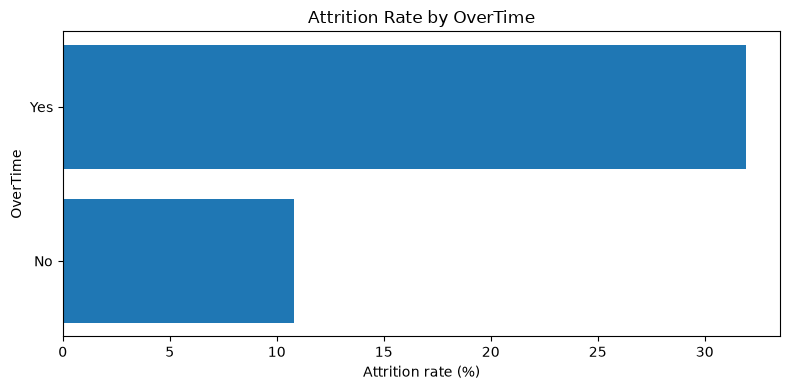

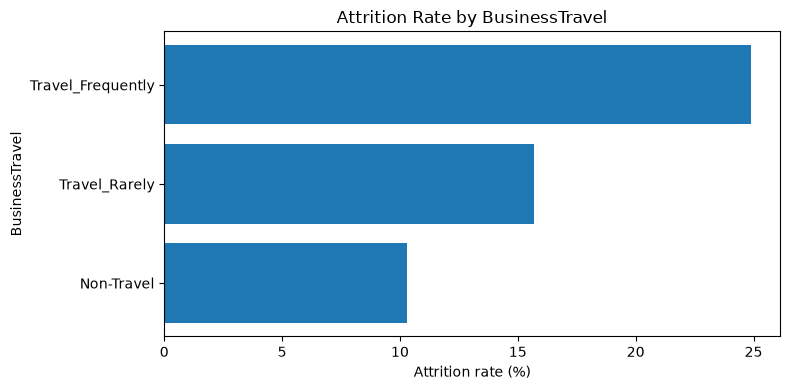

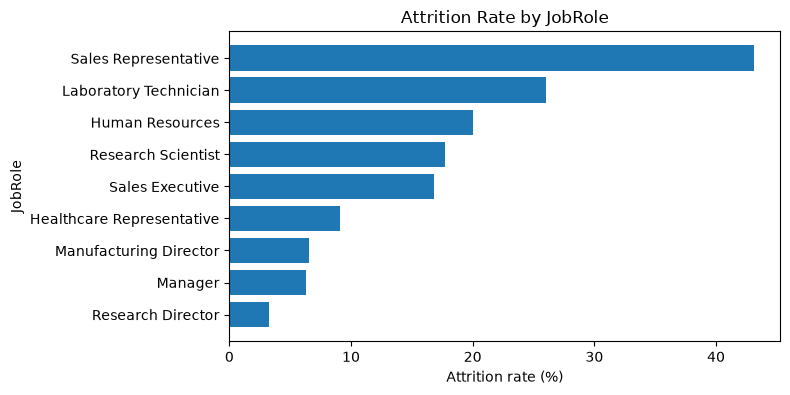

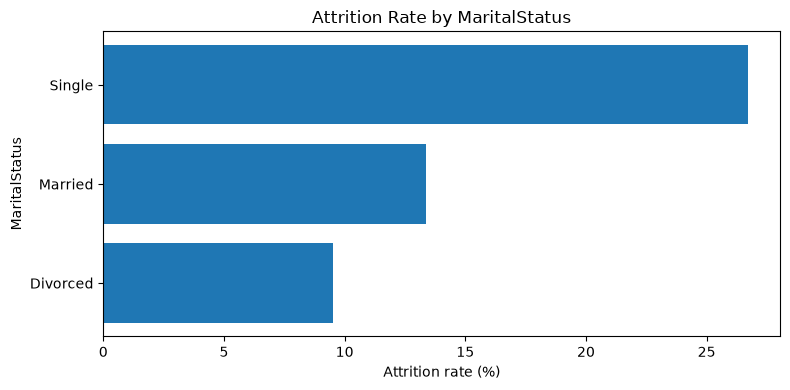

In [16]:
cat_relationships = [
    "OverTime",
    "BusinessTravel",
    "JobRole",
    "MaritalStatus",
]

for feature in cat_relationships:
    table = attrition_rate_table(train, feature).sort_values(
        "attrition_rate", ascending=True
    )

    fig_height = max(4, 0.45 * len(table))
    fig, ax = plt.subplots(figsize=(8, fig_height))
    ax.barh(table[feature].astype(str), table["attrition_rate"])
    ax.set_title(f"Attrition Rate by {feature}")
    ax.set_xlabel("Attrition rate (%)")
    ax.set_ylabel(feature)
    plt.tight_layout()
    plt.show()

## 14. Satisfaction and Ordinal HR Measures

In [17]:
ordinal_features = [
    "Education",
    "EnvironmentSatisfaction",
    "JobInvolvement",
    "JobSatisfaction",
    "PerformanceRating",
    "RelationshipSatisfaction",
    "WorkLifeBalance",
]

for feature in ordinal_features:
    table = (
        train.groupby(feature)[TARGET]
        .agg(["count", "mean"])
        .reset_index()
        .rename(columns={"mean": "attrition_rate"})
    )
    table["attrition_rate"] *= 100
    print(f"\n{feature}")
    display(table)


Education


,Education,count,attrition_rate
0,1,131,19.847
1,2,208,14.904
2,3,410,18.537
3,4,276,15.942
4,5,33,6.061



EnvironmentSatisfaction


,EnvironmentSatisfaction,count,attrition_rate
0,1,209,27.273
1,2,200,17.500
2,3,335,14.030
3,4,314,12.739



JobInvolvement


...

,PerformanceRating,count,attrition_rate
0,3,899,16.796
1,4,159,17.610



RelationshipSatisfaction


,RelationshipSatisfaction,count,attrition_rate
0,1,201,22.886
1,2,210,15.238
2,3,324,15.123
3,4,323,16.099



WorkLifeBalance


,WorkLifeBalance,count,attrition_rate
0,1,56,32.143
1,2,251,17.928
2,3,638,14.734
3,4,113,19.469


## 15. Distance from Home by Job Role and Attrition

In [18]:
distance_role = (
    train.groupby(["JobRole", TARGET])["DistanceFromHome"]
    .agg(["count", "mean", "median"])
    .reset_index()
)

display(distance_role)

,JobRole,Attrition,count,mean,median
0,Healthcare Representative,0,80,9.225,7.000
1,Healthcare Representative,1,8,17.250,17.500
2,Human Resources,0,24,7.625,5.500
3,Human Resources,1,6,9.667,7.500
4,Laboratory Technician,0,139,9.014,7.000
5,Laboratory Technician,1,49,9.612,7.000
6,Manager,0,74,7.297,4.000
7,Manager,1,5,10.000,2.000
8,Manufacturing Director,0,100,9.030,7.000
9,Manufacturing Director,1,7,10.571,8.000


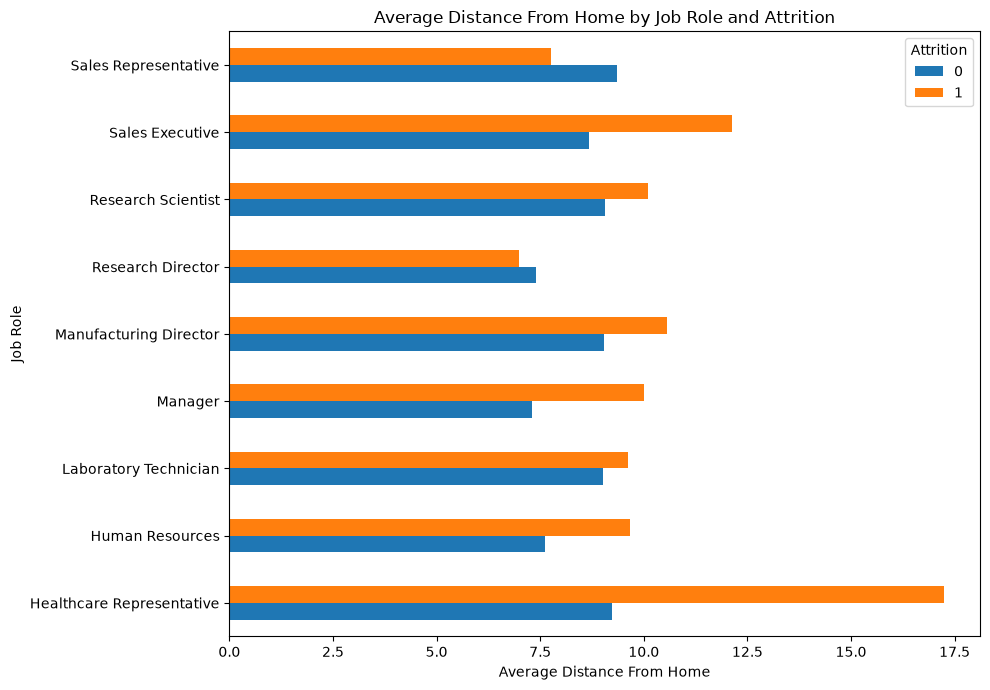

In [19]:
distance_pivot = train.pivot_table(
    index="JobRole",
    columns=TARGET,
    values="DistanceFromHome",
    aggfunc="mean"
)

distance_pivot.plot(kind="barh", figsize=(10, 7))
plt.title("Average Distance From Home by Job Role and Attrition")
plt.xlabel("Average Distance From Home")
plt.ylabel("Job Role")
plt.tight_layout()
plt.show()

## 16. Average Monthly Income by Education and Attrition

In [20]:
income_education = (
    train.groupby(["Education", TARGET])["MonthlyIncome"]
    .agg(["count", "mean", "median"])
    .reset_index()
)

display(income_education)

,Education,Attrition,count,mean,median
0,1,0,105,"5,750.724","3,904.000"
1,1,1,26,"4,695.077","3,152.000"
2,2,0,177,"6,968.299","5,021.000"
3,2,1,31,"4,400.161","4,284.000"
4,3,0,334,"7,003.892","5,312.500"
5,3,1,76,"4,826.513","2,897.500"
6,4,0,232,"7,406.927","5,667.000"
7,4,1,44,"5,385.727","4,259.500"
8,5,0,31,"7,841.032","5,679.000"
9,5,1,2,"4,996.000","4,996.000"


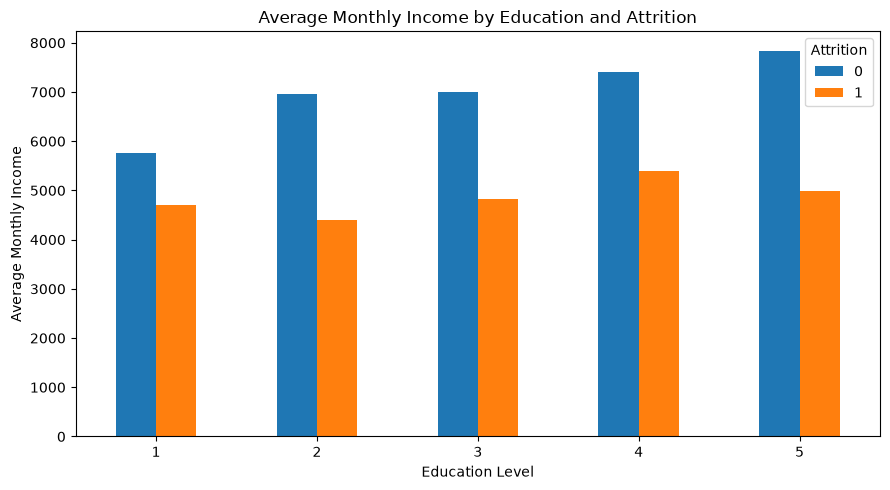

In [21]:
income_pivot = train.pivot_table(
    index="Education",
    columns=TARGET,
    values="MonthlyIncome",
    aggfunc="mean"
)

income_pivot.plot(kind="bar", figsize=(9, 5))
plt.title("Average Monthly Income by Education and Attrition")
plt.xlabel("Education Level")
plt.ylabel("Average Monthly Income")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 17. Numeric Correlation with Attrition

,correlation_with_attrition
TotalWorkingYears,-0.177
Age,-0.172
JobLevel,-0.169
StockOptionLevel,-0.164
MonthlyIncome,-0.164
YearsInCurrentRole,-0.159
YearsWithCurrManager,-0.156
JobInvolvement,-0.150
YearsAtCompany,-0.135
EnvironmentSatisfaction,-0.133


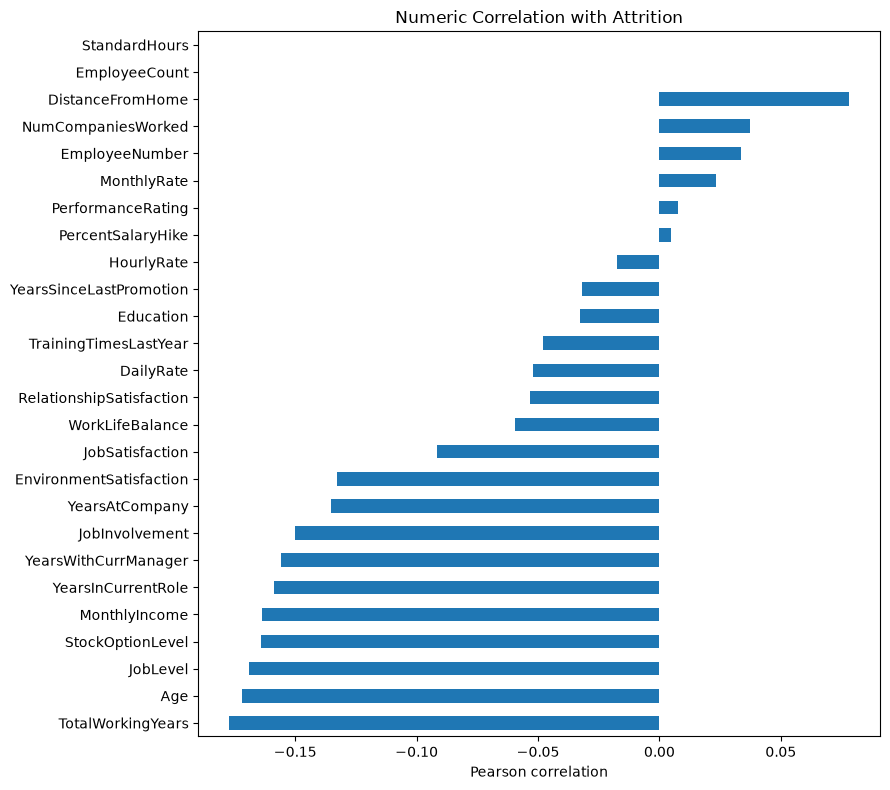

In [22]:
num_corr = (
    train[num_cols]
    .corr(numeric_only=True)[TARGET]
    .drop(TARGET)
    .sort_values()
)

display(
    num_corr
    .rename("correlation_with_attrition")
    .to_frame()
)

fig, ax = plt.subplots(figsize=(9, 8))
num_corr.plot(kind="barh", ax=ax)
ax.set_title("Numeric Correlation with Attrition")
ax.set_xlabel("Pearson correlation")
plt.tight_layout()
plt.show()

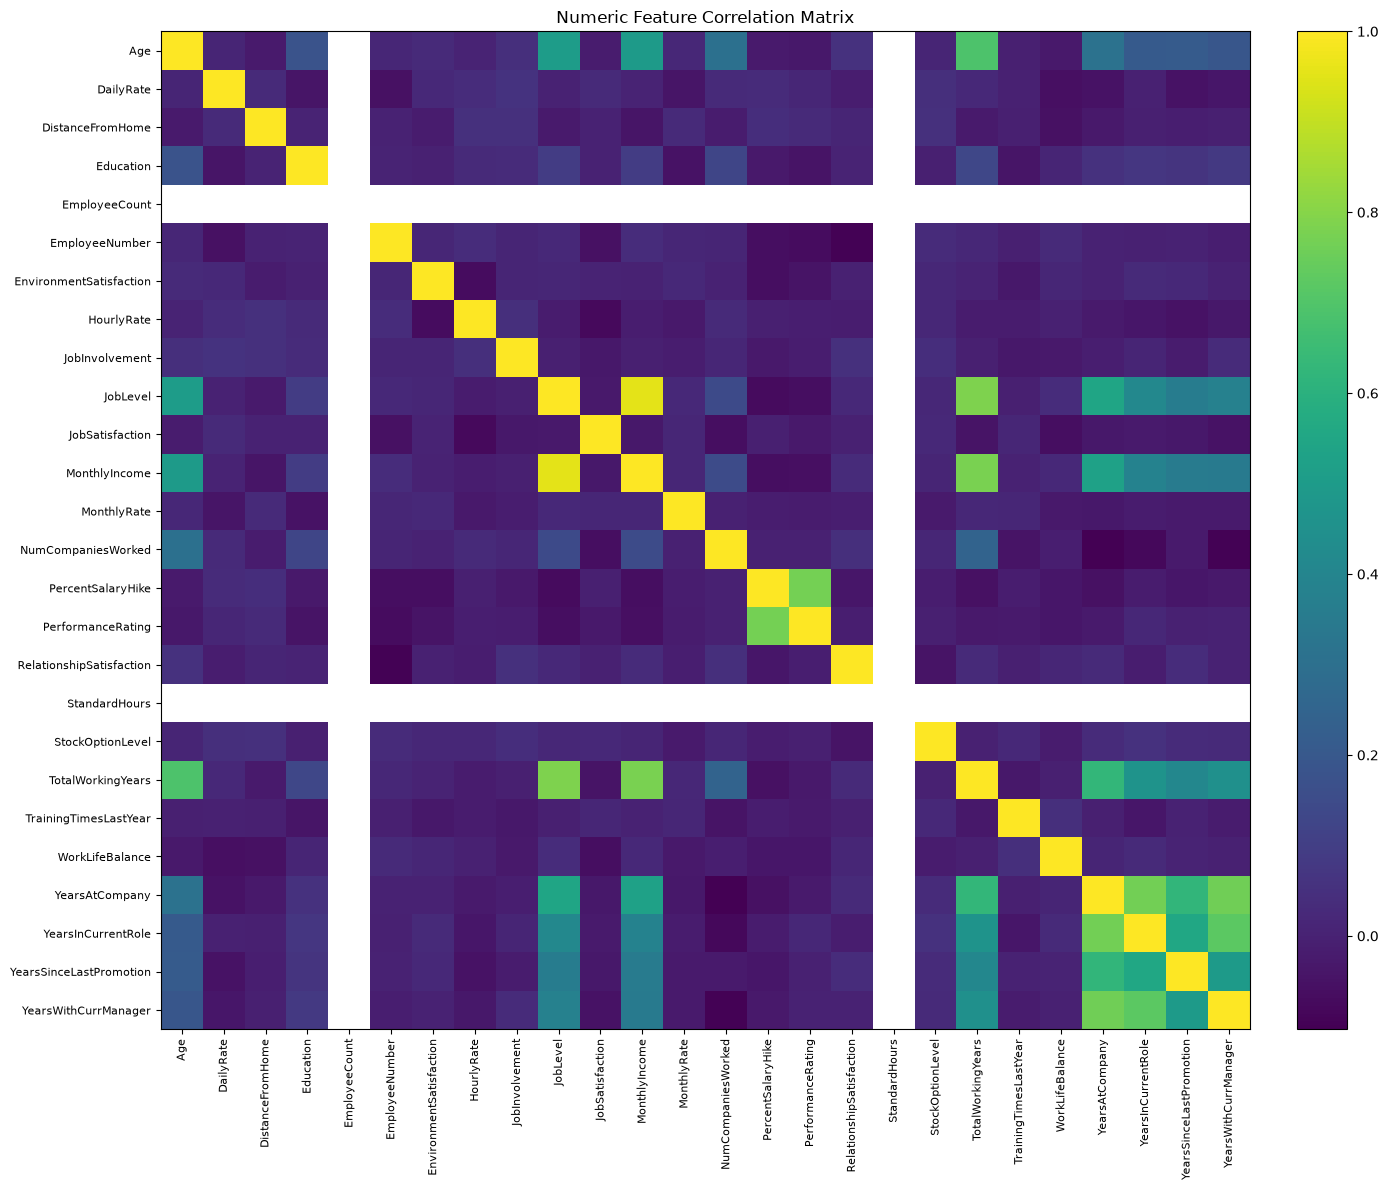

In [23]:
corr = train[num_preds].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(corr, aspect="auto")
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.index)))
ax.set_xticklabels(corr.columns, rotation=90, fontsize=8)
ax.set_yticklabels(corr.index, fontsize=8)
ax.set_title("Numeric Feature Correlation Matrix")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

In [24]:
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

strong_pairs = (
    upper.stack()
    .rename("correlation")
    .reset_index()
    .rename(columns={"level_0": "feature_1", "level_1": "feature_2"})
)

strong_pairs["abs_correlation"] = strong_pairs["correlation"].abs()

display(
    strong_pairs.sort_values("abs_correlation", ascending=False).head(20)
)

,feature_1,feature_2,correlation,abs_correlation
245,JobLevel,MonthlyIncome,0.954,0.954
253,JobLevel,TotalWorkingYears,0.787,0.787
305,MonthlyIncome,TotalWorkingYears,0.778,0.778
379,PercentSalaryHike,PerformanceRating,0.770,0.770
595,YearsAtCompany,YearsInCurrentRole,0.763,0.763
597,YearsAtCompany,YearsWithCurrManager,0.762,0.762
623,YearsInCurrentRole,YearsWithCurrManager,0.722,0.722
19,Age,TotalWorkingYears,0.690,0.690
516,TotalWorkingYears,YearsAtCompany,0.627,0.627
596,YearsAtCompany,YearsSinceLastPromotion,0.623,0.623


## 18. Save Summary

In [25]:
from src.config import RESULTS_DIR

summary = pd.DataFrame([
    ["train_rows", len(train)],
    ["train_columns", train.shape[1]],
    ["train_missing_cells", int(train.isna().sum().sum())],
    ["train_duplicate_rows", int(train.duplicated().sum())],
    ["constant_columns", ", ".join(const_cols)],
    ["unique_per_row_columns", ", ".join(unique_per_row_columns)],
    ["attrition_rate", float(train[TARGET].mean())],
    ["majority_class_accuracy", float(majority_accuracy)],
    ["unrealistic_value_check", int(unrealistic_value_check_results["violations"].sum())],
], columns=["item", "value"])

display(summary)

summary.to_csv(RESULTS_DIR / "data_audit_summary.csv", index=False)
outlier_report.to_csv(RESULTS_DIR / "iqr_outlier_report.csv", index=False)

print("Summary saved to:", RESULTS_DIR)

,item,value
0,train_rows,1058
1,train_columns,35
2,train_missing_cells,0
3,train_duplicate_rows,0
4,constant_columns,"EmployeeCount, Over18, StandardHours"
5,unique_per_row_columns,EmployeeNumber
6,attrition_rate,0.169
7,majority_class_accuracy,0.831
8,unrealistic_value_check,0


Summary saved to: C:\Users\jeffh\PycharmProjects\employee-attrition\results
